$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 2.9

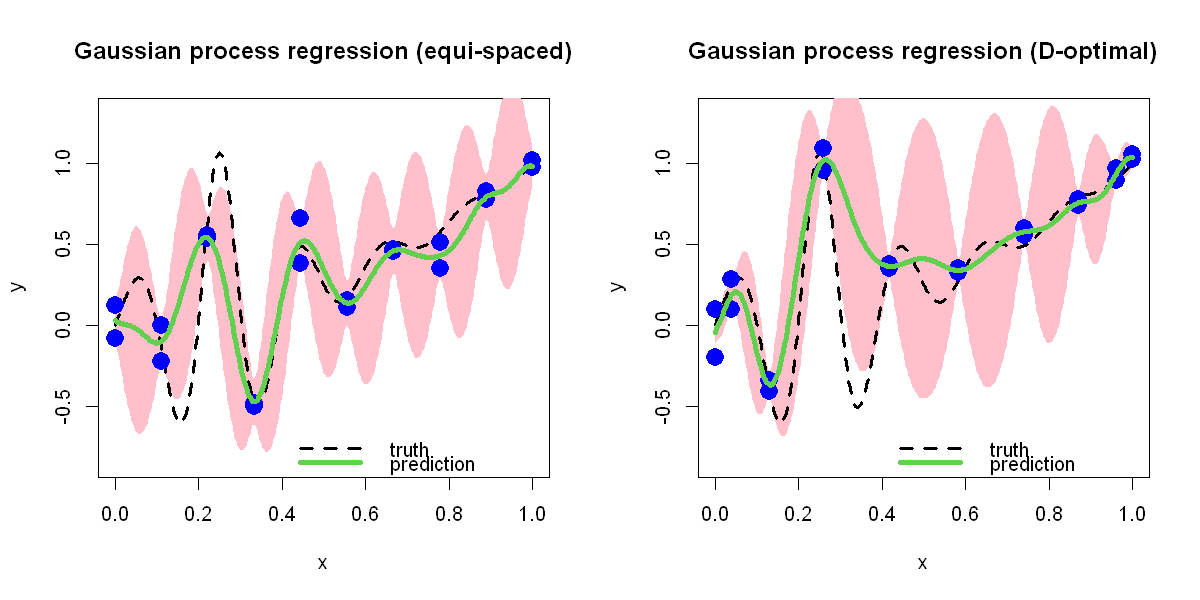

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 背景信息

再次采用一维测试函数 $$h(x)=\frac{\sin(10\pi x)}{1+64(x-.25)}+x^{2},x\in[0,1]$$ 生成的 20 组观测数据.借助 R 语言程序包拟合高斯过程回归,选用高斯相关函数 $R(u-v)=\exp(-(u-v)^{2}/\theta^{2})$.分别基于等间距测点,九次多项式 D 最优测点两组方案得到的预测曲线与 95% 置信区间绘制于图 2.9.不难看出,其预测结果与核岭回归大致相近,但高斯过程回归的优势在于可输出预测的不确定区间.对比图 2.6,图 2.7 右侧子图中的八次多项式拟合,高斯过程回归无论是预测曲线还是不确定区间效果均大幅更优.高斯过程回归的不确定区间具备合理的变化规律:数据密集区域区间更窄,数据稀疏区域区间更宽.

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 指令

创建画布宽 10 英寸,高 5 英寸.将画布分为 1x2.定义函数 $$h(x)=\frac{\sin(10\pi x)}{1+64(x-.25)}+x^{2},x\in[0,1],$$ 令其为 `f`.取 $[0,1]$ 上的 301 个点作为绘图点,令其为 `test`.计算其对应的函数值,令其为 `true`.等间距取 $[0,1]$ 上的 10 个点作为观测点,重复 2 次,令其为 `D`.设置随机种子为 `5`,从均值为 0,标准差为 `.1` 的正态分布中随机抽取 20 个数据作为噪声叠加到观测点对应的观测值上,组成含噪声的观测值,令其为 `y`.

```r
options(repr.plot.width=10,repr.plot.height=5)
par(mfrow=c(1,2))
f=function(x)sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
test=seq(0,1,length=301)
true=f(test)
n=10
re=2
D=((1:n)-1)/(n-1)
D=rep(D,re)
set.seed(5)
e=rnorm(n*re,sd=.1)
y=f(D)+e

使用 R 包 `rkriging` 中的函数 `Fit.Kriging` 对观测值进行高斯过程回归,其中使用回归而非插值,选用高斯核,返回的拟合对象命名为 `a`.使用 `Predict.Kriging` 函数在绘图点上利用拟合结果进行预测,返回的列表命名为 `pred`.取列表中的 `mean` 列为均值,`sd` 列为标准差,利用 3 $\sigma$ 原则得出近似 95% 预测区间的上下界,令其为 `low` 与 `up`.创建绘制真实函数图像的空白画布,其中 $x$ 轴标注为 `x`,$y$ 轴标注为 `y`,$y$ 轴显示范围为 $[\min(y)-.25,\max(y)+.25]$,主标题为 `Gaussian process regression (equi-spaced)`.叠加预测区间多边形,其中颜色为粉色,不显示边框.叠加真实函数图像,其中曲线类型为虚线,线宽为 3.叠加观测点,其中点的类型为实心圆点,放缩系数为 2,颜色为蓝色.叠加预测曲线,其中颜色为绿色,线宽为 4.添加图例,位置在右下角,图例内容为 `truth` 与 `prediction` 及其对应的曲线类型,颜色,线宽,不显示图例边框.

```r
library(rkriging)
a=Fit.Kriging(D,y,interpolation=FALSE,kernel.parameters=list(type="Gaussian"))
pred=Predict.Kriging(a,test)
low=pred$mean-2*pred$sd
up=pred$mean+2*pred$sd
plot(test,true,type="n",xlab="x",ylab="y",ylim=c(min(true)-.25,max(true)+.25),main="Gaussian process regression (equi-spaced)")
polygon(c(test,rev(test)),c(low,rev(up)),col="pink",border=NA)
lines(test,true,lty=2,lwd=3)
points(cbind(D,y),pch=16,cex=2,col="blue")
lines(test,pred$mean,col=3,lwd=4)
legend("bottomright",legend=c("truth","prediction"),lty=c(2,1),col=c(1,3),lwd=c(3,4),bty="n")
```

将 `test` 的范围放缩至 $[-1,1]$,封装成数据框命名为 `cand_df`.使用 R 包 `AlgDesign` 中的 `optFederov` 函数,通过实验设计选取观察点,其中公式为 9 次多项式,实验次数为 `n`,候选集为 `cand_df`,要求精确设计(即给出每个点实验次数的具体次数而不是概率),返回列表命名为 `a`.取其 `design` 数据框中的第一列为最终选取的 10 个观察点.重复选 2 次,将取值范围还原回 $[0,1]$,令其为 `D`.将噪声加到 `f(x)` 上组成带有噪声的观测值,令其为 `y`.高斯过程与绘图要求同上,只是图像主标题变为 `Gaussian process regression (D-optimal)`.将画布还原回 1x1.

```r
cand_df=data.frame(x=2*test-1)
library(AlgDesign)
a=optFederov(~1+x+I(x^2)+I(x^3)+I(x^4)+I(x^5)+I(x^6)+I(x^7)+I(x^8)+I(x^9),nTrials=n,data=cand_df,approximate=FALSE)
D=rep(c(a$design[,1]),re)
D=(D+1)/2
D=rep(D,re)
e=rnorm(n*re,sd=.1)
y=f(D)+e

a=Fit.Kriging(D,y,interpolation=FALSE,kernel.parameters=list(type="Gaussian"))
pred=Predict.Kriging(a,test)
low=pred$mean-2*pred$sd
up=pred$mean+2*pred$sd
plot(test,true,type="n",xlab="x",ylab="y",ylim=c(min(true)-.25,max(true)+.25),main="Gaussian process regression (D-optimal)")
polygon(c(test,rev(test)),c(low,rev(up)),col="pink",border=NA)
lines(test,true,lty=2,lwd=3)
points(cbind(D,y),pch=16,cex=2,col="blue")
lines(test,pred$mean,col=3,lwd=4)
legend("bottomright",legend=c("truth","prediction"),lty=c(2,1),col=c(1,3),lwd=c(3,4),bty="n")
par(mfrow=c(1,1))
```

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 最终效果

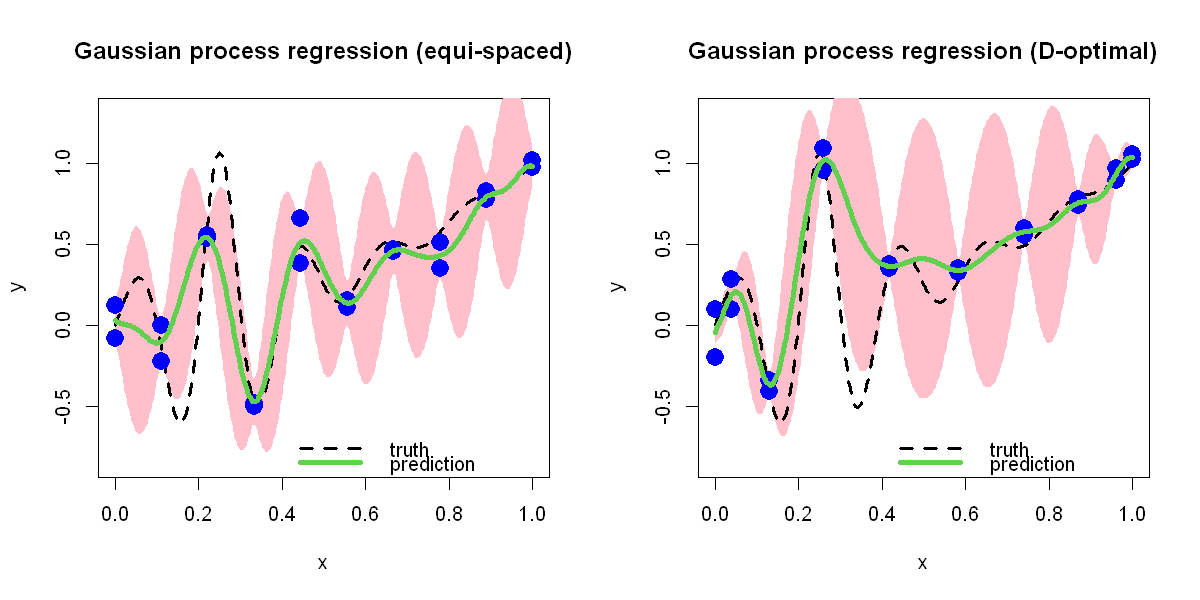

In [ ]:
# 图 2.9

options(repr.plot.width=10,repr.plot.height=5)
par(mfrow=c(1,2))
f=function(x)sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
test=seq(0,1,length=301)
true=f(test)
n=10
re=2
D=((1:n)-1)/(n-1)
D=rep(D,re)
set.seed(5)
e=rnorm(n*re,sd=.1)
y=f(D)+e

library(rkriging)
a=Fit.Kriging(D,y,interpolation=FALSE,kernel.parameters=list(type="Gaussian"))
pred=Predict.Kriging(a,test)
low=pred$mean-2*pred$sd
up=pred$mean+2*pred$sd
plot(test,true,type="n",xlab="x",ylab="y",ylim=c(min(true)-.25,max(true)+.25),main="Gaussian process regression (equi-spaced)")
polygon(c(test,rev(test)),c(low,rev(up)),col="pink",border=NA)
lines(test,true,lty=2,lwd=3)
points(cbind(D,y),pch=16,cex=2,col="blue")
lines(test,pred$mean,col=3,lwd=4)
legend("bottomright",legend=c("truth","prediction"),lty=c(2,1),col=c(1,3),lwd=c(3,4),bty="n")

cand_df=data.frame(x=2*test-1)
library(AlgDesign)
a=optFederov(~1+x+I(x^2)+I(x^3)+I(x^4)+I(x^5)+I(x^6)+I(x^7)+I(x^8)+I(x^9),nTrials=n,data=cand_df,approximate=FALSE)
D=rep(c(a$design[,1]),re)
D=(D+1)/2
D=rep(D,re)
e=rnorm(n*re,sd=.1)
y=f(D)+e

a=Fit.Kriging(D,y,interpolation=FALSE,kernel.parameters=list(type="Gaussian"))
pred=Predict.Kriging(a,test)
low=pred$mean-2*pred$sd
up=pred$mean+2*pred$sd
plot(test,true,type="n",xlab="x",ylab="y",ylim=c(min(true)-.25,max(true)+.25),main="Gaussian process regression (D-optimal)")
polygon(c(test,rev(test)),c(low,rev(up)),col="pink",border=NA)
lines(test,true,lty=2,lwd=3)
points(cbind(D,y),pch=16,cex=2,col="blue")
lines(test,pred$mean,col=3,lwd=4)
legend("bottomright",legend=c("truth","prediction"),lty=c(2,1),col=c(1,3),lwd=c(3,4),bty="n")
par(mfrow=c(1,1))

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$